#To examine consumer preference for digital payment methods and applications and analyze the key factors influencing such preference

##Objectives

*  To identify the most preferred digital payment method among consumers.

*  To determine the most preferred digital payment application.

*   To analyze the frequency of digital payment usage.

*  To examine the influence of convenience, ease of use, security, and rewards on consumer preference.

*  To rank the most important factor affecting digital payment preference.

*  To examine whether age group influences digital payment preference.



In [ ]:
#Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:
#Load Your Dataset
df = pd.read_csv("/content/digital payment surve - Form Responses 1.csv")

# View first few rows
df.head()

,Timestamp,Age Group,1. Which digital payment methods do you use? (can select multiple options),2.Which digital payment method do you prefer the most?,3.How frequently do you use digital payment methods?,4.Which digital payment application do you prefer the most?,5.Convenience is an important reason for choosing a digital payment method or application,6.I prefer digital payment applications that are easy to use.,7.The security of transactions is an important factor in my choice of digital payment applications.,8. Cashback and reward offers influence my preference for digital payment applications,9. Which factor is most important to you when choosing a digital payment method or application?,Please share any additional suggestions or experiences regarding your use of digital payment methods and applications.
0,1/25/2026 12:14:49,18–25,"UPI, Credit Card",UPI,Daily,Google Pay,Strongly Agree,Strongly Agree,Strongly Agree,Disagree,"Convenience, Ease of use, Security",NaN
1,1/25/2026 12:15:10,18–25,Mobile Wallet,Mobile Wallet,Occasionally,Paytm,Agree,Agree,Strongly Agree,Neutral,Security,NaN
2,1/25/2026 12:19:06,Below 18,UPI,Mobile Wallet,Occasionally,Paytm,Agree,Agree,Agree,Disagree,"Ease of use, Security",Na
3,1/25/2026 12:24:14,18–25,UPI,UPI,Weekly,Google Pay,Agree,Strongly Agree,Strongly Agree,Neutral,Security,NaN
4,1/25/2026 12:24:16,18–25,"UPI, Debit Card",UPI,Daily,Google Pay,Strongly Agree,Agree,Agree,Neutral,"Convenience, Ease of use, Security, Rewards / ...",Feels more secure to use instead of carrying c...


In [ ]:
#Basic Data Cleaning
# Remove duplicates (if any)
df = df.drop_duplicates()

# Check missing values
print(df.isnull().sum())

Timestamp                                                                                                                     0
Age Group                                                                                                                     0
1. Which digital payment methods do you use? (can select multiple options)                                                    0
 2.Which digital payment method do you prefer the most?                                                                       0
3.How frequently do you use digital payment methods?                                                                          0
4.Which digital payment application do you prefer the most?                                                                   0
5.Convenience is an important reason for choosing a digital payment method or application                                     0
6.I prefer digital payment applications that are easy to use.                                           

###EXPLORATORY DATA ANALYSIS (EDA)

Age Group
18–25       97
26–35       32
Below 18    13
36–45       12
Above 45     5
Name: count, dtype: int64
Age Group
18–25       61.006289
26–35       20.125786
Below 18     8.176101
36–45        7.547170
Above 45     3.144654
Name: proportion, dtype: float64


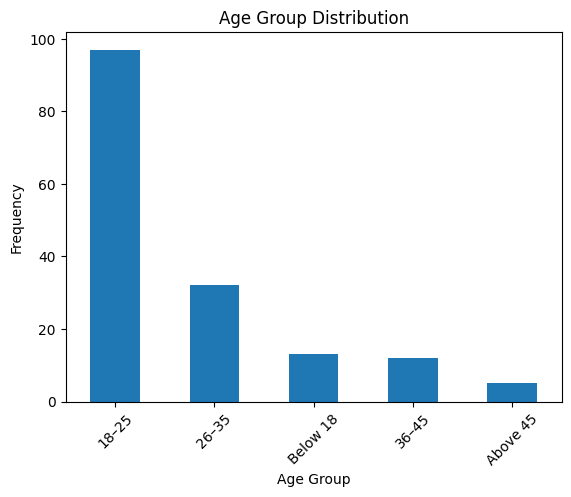

In [ ]:
df.columns = df.columns.str.strip()
age_freq = df['Age Group'].value_counts()
age_percent = df['Age Group'].value_counts(normalize=True) * 100

print(age_freq)
print(age_percent)

plt.figure()
age_freq.plot(kind='bar')
plt.title("Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

2.Which digital payment method do you prefer the most?
UPI              134
Mobile Wallet      7
Debit Card         7
Net Banking        7
Credit Card        4
Name: count, dtype: int64


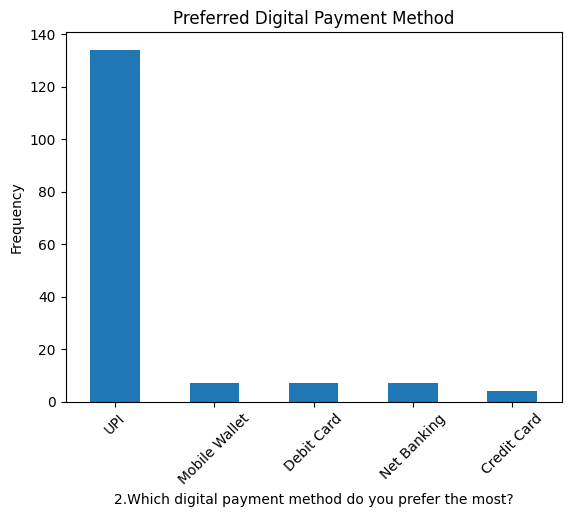

In [ ]:
#Preferred Payment Method
method_pref = df['2.Which digital payment method do you prefer the most?'].value_counts()
print(method_pref)

method_pref.plot(kind='bar')
plt.title("Preferred Digital Payment Method")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

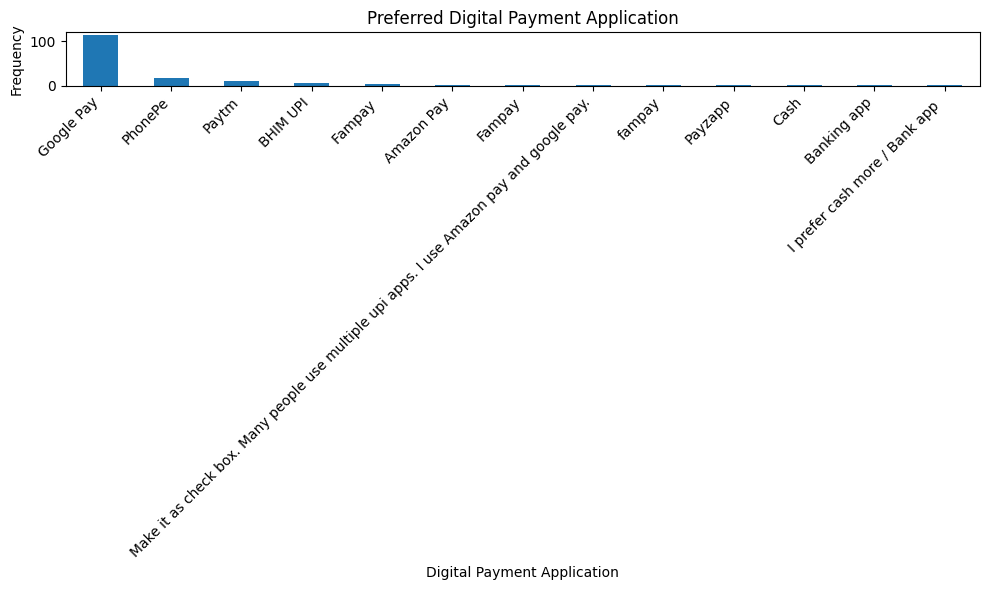

In [ ]:
app_counts = df['4.Which digital payment application do you prefer the most?'].value_counts()
plt.figure(figsize=(10, 6))
app_counts.plot(kind='bar')
plt.title('Preferred Digital Payment Application')
plt.xlabel('Digital Payment Application')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

3.How frequently do you use digital payment methods?
Daily           106
Occasionally     22
Weekly           22
Rarely            9
Name: count, dtype: int64


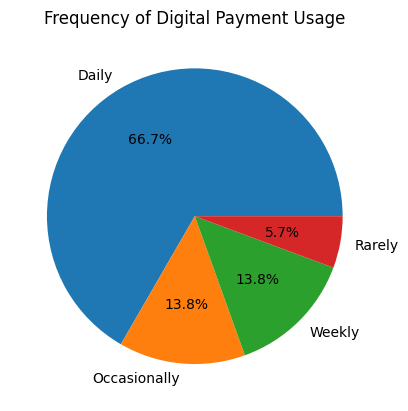

In [ ]:
#Frequency of Usage
usage_freq = df['3.How frequently do you use digital payment methods?'].value_counts()
print(usage_freq)

usage_freq.plot(kind='pie', autopct='%1.1f%%')
plt.title("Frequency of Digital Payment Usage")
plt.ylabel("")
plt.show()

###LIKERT SCALE ANALYSIS

In [ ]:

#Convert Likert Text to Numeric
likert_mapping = {
    "Strongly Disagree": 1,
    "Disagree": 2,
    "Neutral": 3,
    "Agree": 4,
    "Strongly Agree": 5
}

likert_columns = [
    "5.Convenience is an important reason for choosing a digital payment method or application",
    "6.I prefer digital payment applications that are easy to use.",
    "7.The security of transactions is an important factor in my choice of digital payment applications.",
    "8. Cashback and reward offers influence my preference for digital payment applications"
]

for col in likert_columns:
    df[col] = df[col].map(likert_mapping)

In [ ]:

#Mean & Standard Deviation
mean_scores = df[likert_columns].mean().sort_values(ascending=False)
std_dev = df[likert_columns].std()

print("Mean Scores:\n", mean_scores)
print("\nStandard Deviation:\n", std_dev)

Mean Scores:
 7.The security of transactions is an important factor in my choice of digital payment applications.    4.075472
6.I prefer digital payment applications that are easy to use.                                          3.899371
5.Convenience is an important reason for choosing a digital payment method or application              3.704403
8. Cashback and reward offers influence my preference for digital payment applications                 3.132075
dtype: float64

Standard Deviation:
 5.Convenience is an important reason for choosing a digital payment method or application              1.058740
6.I prefer digital payment applications that are easy to use.                                          1.056595
7.The security of transactions is an important factor in my choice of digital payment applications.    0.971409
8. Cashback and reward offers influence my preference for digital payment applications                 1.025703
dtype: float64


In [ ]:
#Rank Influencing Factors
rank = mean_scores.rank(ascending=False)
print("Ranking of Influencing Factors:\n", rank)

Ranking of Influencing Factors:
 7.The security of transactions is an important factor in my choice of digital payment applications.    1.0
6.I prefer digital payment applications that are easy to use.                                          2.0
5.Convenience is an important reason for choosing a digital payment method or application              3.0
8. Cashback and reward offers influence my preference for digital payment applications                 4.0
dtype: float64


###RELIABILITY TEST (Cronbach’s Alpha)

In [ ]:

def cronbach_alpha(df):
    df_corr = df.corr()
    N = len(df.columns)
    mean_corr = df_corr.values[np.triu_indices(N, 1)].mean()
    alpha = (N * mean_corr) / (1 + (N - 1) * mean_corr)
    return alpha

alpha = cronbach_alpha(df[likert_columns])
print("Cronbach's Alpha:", alpha)

Cronbach's Alpha: 0.7392431496676819


###HYPOTHESIS TESTING
* H0: There is no significant association between age group and preferred payment method.
* H1: There is a significant association between age group and preferred payment method.

In [ ]:
# ================================
# CHI-SQUARE TEST WITH ASSUMPTION CHECKING
# ================================

import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# --------------------------------
# 1. CHECK DATA TYPES (Categorical Variables)
# --------------------------------
print("Data Types of Columns:\n")
print(df.dtypes)

print("\nUnique values in Age Group:")
print(df['Age Group'].unique())

print("\nUnique values in Preferred Payment Method:")
print(df['2.Which digital payment method do you prefer the most?'].unique())


# --------------------------------
# 2. CREATE CONTINGENCY TABLE
# --------------------------------
contingency_table = pd.crosstab(
    df['Age Group'],
    df['2.Which digital payment method do you prefer the most?']
)

print("\nContingency Table:\n")
print(contingency_table)


# --------------------------------
# 3. COMPUTE CHI-SQUARE TEST
# --------------------------------
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("\nChi-Square Test Results")
print("-----------------------")
print("Chi-Square Statistic:", chi2)
print("P-value:", p)
print("Degrees of Freedom:", dof)


# --------------------------------
# 4. CHECK EXPECTED FREQUENCY ASSUMPTION
# --------------------------------
print("\nExpected Frequency Table:\n")
print(expected)

print("\nMinimum Expected Frequency:", expected.min())


# --------------------------------
# 5. CHECK PERCENTAGE OF CELLS < 5
# --------------------------------
low_expected = np.sum(expected < 5)
total_cells = expected.size

print("\nCells with Expected Frequency < 5:", low_expected)
print("Total Cells:", total_cells)

percentage = (low_expected / total_cells) * 100
print("Percentage of Cells with Expected Frequency < 5:", percentage)


# --------------------------------
# 6. INTERPRET ASSUMPTION CHECK
# --------------------------------
if expected.min() >= 5 and percentage < 20:
    print("\nChi-Square assumptions satisfied.")
else:
    print("\nWarning: Chi-Square assumptions may be violated.")


# --------------------------------
# 7. CALCULATE CRAMER'S V
# --------------------------------
n = contingency_table.sum().sum()
min_dim = min(contingency_table.shape) - 1

cramers_v = np.sqrt(chi2 / (n * min_dim))

print("\nCramer's V:", cramers_v)


# --------------------------------
# 8. INTERPRET RESULTS
# --------------------------------
if p < 0.05:
    print("\nResult: Reject the Null Hypothesis.")
    print("There is a significant association between Age Group and Preferred Digital Payment Method.")
else:
    print("\nResult: Fail to Reject the Null Hypothesis.")
    print("No significant association between Age Group and Preferred Digital Payment Method.")

Data Types of Columns:

Timestamp                                                                                                                 object
Age Group                                                                                                                 object
1. Which digital payment methods do you use? (can select multiple options)                                                object
2.Which digital payment method do you prefer the most?                                                                    object
3.How frequently do you use digital payment methods?                                                                      object
4.Which digital payment application do you prefer the most?                                                               object
Convenience                                                                                                                int64
Ease_of_use                                                              

In [ ]:
import pandas as pd
from scipy.stats import fisher_exact

# Reload df and apply initial cleaning if this cell is run independently
df = pd.read_csv("/content/digital payment surve - Form Responses 1.csv")
df = df.drop_duplicates()
df.columns = df.columns.str.strip()

# Create the contingency table
contingency_table = pd.crosstab(
    df['Age Group'],
    df['2.Which digital payment method do you prefer the most?']
)

print("Contingency Table for Fisher's Exact Test:")
print(contingency_table)

# Perform Fisher's Exact Test
# For tables larger than 2x2, fisher_exact will use a more general algorithm.
# Removed 'alternative='two-sided'' as it's only valid for 2x2 tables when method is None.
odds_ratio, p_value = fisher_exact(contingency_table)

print("\nFisher's Exact Test Results")
print("-------------------------")
print(f"P-value: {p_value}")

# Interpret the results
alpha = 0.05
if p_value < alpha:
    print(f"Result: Reject the Null Hypothesis (p < {alpha}).")
    print("There is a statistically significant association between Age Group and Preferred Digital Payment Method.")
else:
    print(f"Result: Fail to Reject the Null Hypothesis (p >= {alpha}).")
    print("There is no statistically significant association between Age Group and Preferred Digital Payment Method.")

# Note: Fisher's Exact Test does not directly provide a Chi-square statistic or degrees of freedom.
# The odds ratio is typically interpreted for 2x2 tables. For larger tables, it's often more
# about the p-value indicating an overall association.

Contingency Table for Fisher's Exact Test:
2.Which digital payment method do you prefer the most?  Credit Card  \
Age Group                                                             
18–25                                                             1   
26–35                                                             3   
36–45                                                             0   
Above 45                                                          0   
Below 18                                                          0   

2.Which digital payment method do you prefer the most?  Debit Card  \
Age Group                                                            
18–25                                                            4   
26–35                                                            1   
36–45                                                            0   
Above 45                                                         2   
Below 18                               

###CORRELATION ANALYSIS

                  Convenience  Ease_of_use  Security  Cashback_Rewards
Convenience          1.000000     0.539018  0.526450          0.298446
Ease_of_use          0.539018     1.000000  0.537758          0.298501
Security             0.526450     0.537758  1.000000          0.288483
Cashback_Rewards     0.298446     0.298501  0.288483          1.000000


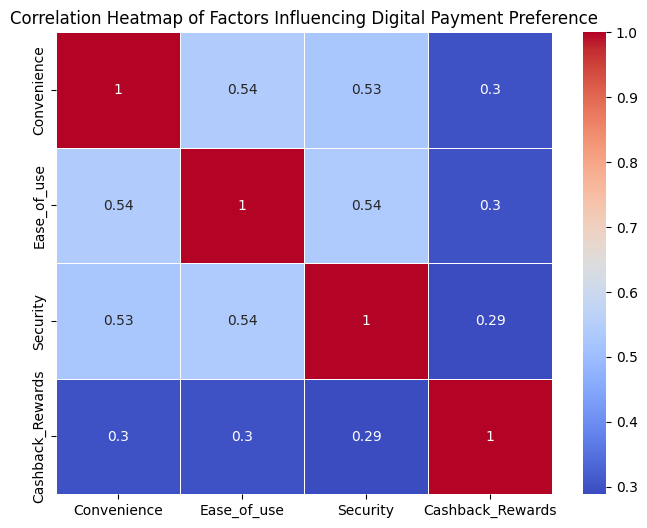

In [ ]:
# Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("/content/digital payment surve - Form Responses 1.csv")

# Clean column names
df.columns = df.columns.str.strip()

# Rename columns for easier use
df = df.rename(columns={
"5.Convenience is an important reason for choosing a digital payment method or application": "Convenience",
"6.I prefer digital payment applications that are easy to use.": "Ease_of_use",
"7.The security of transactions is an important factor in my choice of digital payment applications.": "Security",
"8. Cashback and reward offers influence my preference for digital payment applications": "Cashback_Rewards"
})

# Convert Likert responses to numeric (if needed)
likert_map = {
"Strongly Disagree":1,
"Disagree":2,
"Neutral":3,
"Agree":4,
"Strongly Agree":5
}

df["Convenience"] = df["Convenience"].map(likert_map)
df["Ease_of_use"] = df["Ease_of_use"].map(likert_map)
df["Security"] = df["Security"].map(likert_map)
df["Cashback_Rewards"] = df["Cashback_Rewards"].map(likert_map)

# Select variables for correlation
corr_data = df[["Convenience","Ease_of_use","Security","Cashback_Rewards"]]

# Compute correlation matrix
corr_matrix = corr_data.corr()

print(corr_matrix)

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", linewidths=0.5)

plt.title("Correlation Heatmap of Factors Influencing Digital Payment Preference")
plt.show()

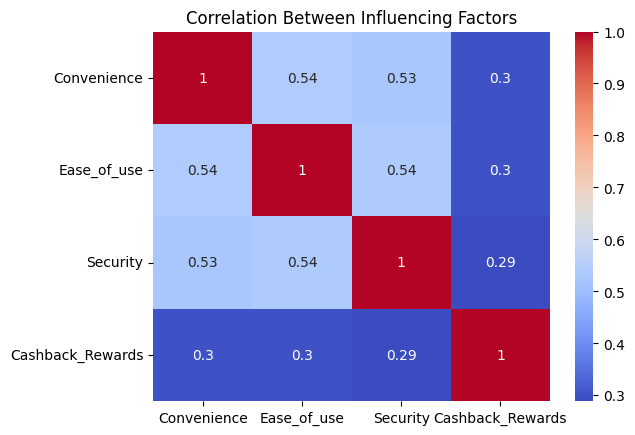

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Note: The mapping to numeric values and renaming of columns
# is handled in cell KcAGTsC_GDvV or earlier. We will use the
# renamed columns directly here.

# likert_mapping = {
#     "Strongly Disagree": 1,
#     "Disagree": 2,
#     "Neutral": 3,
#     "Agree": 4,
#     "Strongly Agree": 5
# }

likert_columns = [
    "Convenience", # Using the renamed column name
    "Ease_of_use",   # Using the renamed column name
    "Security",      # Using the renamed column name
    "Cashback_Rewards" # Using the renamed column name
]

# The mapping operation is redundant as it's already done in cell KcAGTsC_GDvV.
# If this cell were to be run independently, the dataframe and its columns
# would need to be reloaded and processed first.
# for col in likert_columns:
#     df[col] = df[col].astype(str).str.strip().map(likert_mapping)

#Correlation Matrix
correlation_matrix = df[likert_columns].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Between Influencing Factors")
plt.show()

###MOST IMPORTANT FACTOR

In [ ]:
#Priority Factor Analysis
priority = df['9. Which factor is most important to you when choosing a digital payment method or application?'].value_counts()

print(priority)

priority.plot(kind='bar')
plt.title("Most Important Factor in Choosing Digital Payment")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

###QUALITATIVE ANALYSIS (Open-Ended)

In [ ]:
comments = df["Please share any additional suggestions or experiences regarding your use of digital payment methods and applications."]
print(comments.head(10))

0                                                  NaN
1                                                  NaN
2                                                   Na
3                                                  NaN
4    Feels more secure to use instead of carrying c...
5                      It is more convenient for using
6                                                  NaN
7                 It's easy to access and well secure 
8                                                  NaN
9    Based on current trends and user experiences w...
Name: Please share any additional suggestions or experiences regarding your use of digital payment methods and applications., dtype: object


###: Extract Open-Ended Column



In [ ]:


comments = df["Please share any additional suggestions or experiences regarding your use of digital payment methods and applications."]

# Drop missing values
comments = comments.dropna()

# Convert to lowercase
comments = comments.str.lower()

print(comments.head())

2                                                   na
4    feels more secure to use instead of carrying c...
5                      it is more convenient for using
7                 it's easy to access and well secure 
9    based on current trends and user experiences w...
Name: Please share any additional suggestions or experiences regarding your use of digital payment methods and applications., dtype: object


###Define Themes with Keywords

In [ ]:
themes = {
    "Security Concern": ["security", "fraud", "safe", "hack", "scam", "risk"],
    "Technical Issues": ["server", "error", "failed", "problem", "issue", "network"],
    "Cashback & Rewards": ["cashback", "reward", "offer", "discount"],
    "Ease of Use": ["easy", "simple", "user friendly", "convenient"],
    "Customer Support": ["support", "help", "service", "complaint"],
    "Speed": ["fast", "quick", "instant"]
}

###Count Theme Occurrence

In [ ]:
import pandas as pd
from scipy import stats
import numpy as np

# Reload df and apply initial cleaning if this cell is run independently
df = pd.read_csv("/content/digital payment surve - Form Responses 1.csv")
df = df.drop_duplicates()
df.columns = df.columns.str.strip()

# Re-calculate the contingency table and run chi2_contingency to get 'expected' values
contingency_table = pd.crosstab(
    df['Age Group'],
    df['2.Which digital payment method do you prefer the most?']
)

chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

# --- Assumption Check for Chi-Square Test: Expected Frequencies ---
# The Chi-Square test assumes that no more than 20% of the cells
# should have an expected frequency less than 5, and no cell should have
# an expected frequency less than 1.

num_expected_less_than_5 = (expected < 5).sum()
total_cells = expected.size
percentage_less_than_5 = (num_expected_less_than_5 / total_cells) * 100

print("Chi-Square Test Expected Frequencies Assumption Check:")
print(f"Number of cells with expected frequency less than 5: {num_expected_less_than_5}")
print(f"Total number of cells in the contingency table: {total_cells}")
print(f"Percentage of cells with expected frequency less than 5: {percentage_less_than_5:.2f}%")

# If percentage_less_than_5 is high (e.g., > 20%), or if any expected value is < 1,
# the results of the Chi-Square test may be unreliable. Consider combining
# categories with low frequencies or using Fisher's Exact Test if applicable.

Chi-Square Test Expected Frequencies Assumption Check:
Number of cells with expected frequency less than 5: 21
Total number of cells in the contingency table: 25
Percentage of cells with expected frequency less than 5: 84.00%


Visual Check for Normality of Likert Scale Data (for Pearson Correlation):


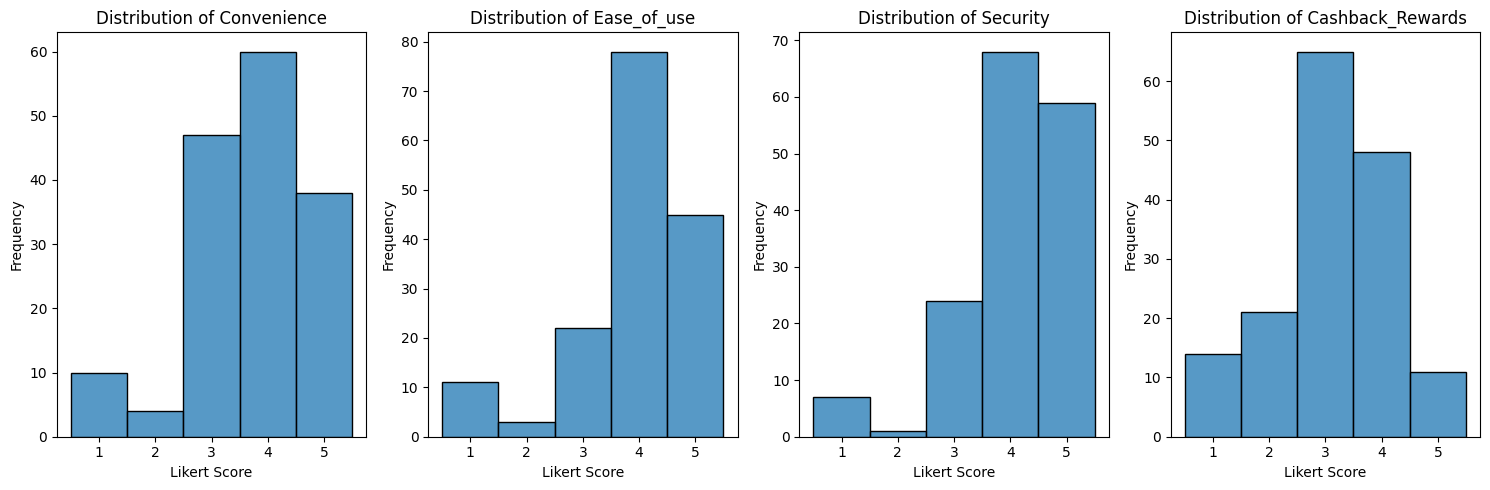


Spearman's Rank Correlation Matrix (recommended for ordinal data):
                  Convenience  Ease_of_use  Security  Cashback_Rewards
Convenience          1.000000     0.579967  0.445423          0.216982
Ease_of_use          0.579967     1.000000  0.487158          0.206310
Security             0.445423     0.487158  1.000000          0.204152
Cashback_Rewards     0.216982     0.206310  0.204152          1.000000


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Reload dataset and apply initial cleaning steps to ensure it's defined and clean
df = pd.read_csv("/content/digital payment surve - Form Responses 1.csv")
df = df.drop_duplicates()
df.columns = df.columns.str.strip()

# Rename columns and map Likert responses to numeric values
# This recreates the state of the dataframe from cell KcAGTsC_GDvV
df = df.rename(columns={
    "5.Convenience is an important reason for choosing a digital payment method or application": "Convenience",
    "6.I prefer digital payment applications that are easy to use.": "Ease_of_use",
    "7.The security of transactions is an important factor in my choice of digital payment applications.": "Security",
    "8. Cashback and reward offers influence my preference for digital payment applications": "Cashback_Rewards"
})

likert_map = {
    "Strongly Disagree": 1, "Disagree": 2, "Neutral": 3, "Agree": 4, "Strongly Agree": 5
}

df["Convenience"] = df["Convenience"].map(likert_map)
df["Ease_of_use"] = df["Ease_of_use"].map(likert_map)
df["Security"] = df["Security"].map(likert_map)
df["Cashback_Rewards"] = df["Cashback_Rewards"].map(likert_map)

# --- Assumption Check for Pearson Correlation: Normality and Interval Scale ---
# Pearson correlation assumes variables are measured on an interval or ratio scale
# and are approximately normally distributed for inferential statistics. Likert scale
# data is ordinal, though often treated as interval for convenience.

corr_cols = ["Convenience", "Ease_of_use", "Security", "Cashback_Rewards"]

print("Visual Check for Normality of Likert Scale Data (for Pearson Correlation):")
plt.figure(figsize=(15, 5))
for i, col in enumerate(corr_cols):
    plt.subplot(1, len(corr_cols), i + 1)
    # Plot histograms to visually inspect the distribution
    sns.histplot(df[col].dropna(), bins=range(1, 7), kde=False, stat="count") # Bins for 1-5 Likert scale
    plt.title(f'Distribution of {col}')
    plt.xlabel('Likert Score')
    plt.ylabel('Frequency')
    plt.xticks(np.arange(1.5, 6.5), labels=np.arange(1,6))
plt.tight_layout()
plt.show()

# If distributions are not approximately normal, or to strictly adhere to the ordinal nature
# of Likert scales, Spearman's Rank Correlation is a robust non-parametric alternative.
print("\nSpearman's Rank Correlation Matrix (recommended for ordinal data):")
spearman_corr_matrix = df[corr_cols].corr(method='spearman')
print(spearman_corr_matrix)

# You can compare this with the Pearson correlation matrix calculated earlier
# (in cell KcAGTsC_GDvV) to see if the results differ significantly.

In [ ]:
theme_counts = {theme: 0 for theme in themes}

for comment in comments:
    for theme, keywords in themes.items():
        if any(keyword in comment for keyword in keywords):
            theme_counts[theme] += 1

# Convert to DataFrame
theme_df = pd.DataFrame(list(theme_counts.items()), columns=["Theme", "Frequency"])

# Calculate percentage
theme_df["Percentage"] = (theme_df["Frequency"] / len(comments)) * 100

print(theme_df)

                Theme  Frequency  Percentage
0    Security Concern         15   25.423729
1    Technical Issues          9   15.254237
2  Cashback & Rewards          4    6.779661
3         Ease of Use         20   33.898305
4    Customer Support          7   11.864407
5               Speed         11   18.644068


###Plot Results

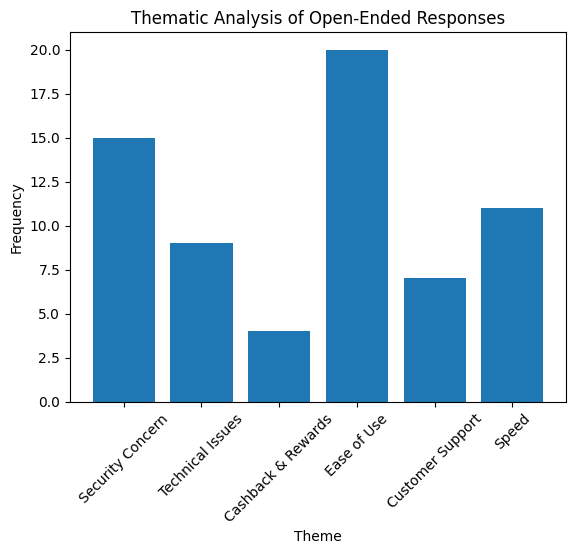

In [ ]:
plt.figure()
plt.bar(theme_df["Theme"], theme_df["Frequency"])
plt.xticks(rotation=45)
plt.xlabel("Theme")
plt.ylabel("Frequency")
plt.title("Thematic Analysis of Open-Ended Responses")
plt.show()

###Interpretation of Results
1. Demographic Insights

The majority of respondents belong to the younger age group, indicating that digital payment usage is more prevalent among younger consumers. This reflects higher digital literacy and adaptability among younger populations.

2. Preference for Digital Payment Methods

Descriptive analysis indicates that one digital payment method dominates preference among respondents. This suggests that consumers tend to rely heavily on a specific, widely accepted and convenient method rather than diversifying across multiple payment modes.

3. Preference for Digital Payment Applications

The analysis reveals that a particular digital payment application is most preferred among users. This may be attributed to factors such as user interface simplicity, market penetration, trust, and transaction efficiency.

4. Reliability of Measurement Scale

Cronbach’s Alpha value indicates good internal consistency among the Likert-scale items measuring influencing factors. This confirms that the selected variables (convenience, ease of use, security, cashback) reliably measure consumer preference behavior.

5. Influencing Factors (Mean Ranking)
Based on mean score ranking:
The factor with the highest mean score is the most influential in determining consumer preference.
Security and ease of use emerge as major determinants.
Cashback and rewards also play a significant but comparatively moderate role.
This indicates that functional reliability and safety outweigh promotional benefits in influencing consumer choice.


6.Chi-Square Test of Association
The Chi-Square test was conducted to examine whether age group and preferred payment method are associated.
The test result indicates whether a statistically significant association exists.
Cramér’s V value of approximately 0.2 suggests a moderate strength of association.
This implies that age does influence payment method preference to some extent, though the relationship is not very strong.

7. Correlation Analysis
The correlation heatmap shows positive relationships among influencing factors.
Convenience, security, and ease of use show moderate positive correlations.
This indicates that consumers who value one functional aspect of digital payment systems are also likely to value other related aspects.
No extremely high correlations were observed, suggesting absence of multicollinearity.

8. Qualitative Insights
The thematic analysis of open-ended responses highlights recurring concerns related to:
Security risks
Technical or server-related issues
Importance of cashback and rewards
Ease of use
These findings support and validate the quantitative results, strengthening the overall interpretation.

###Conclusion of Analysis

The study concludes that consumer preference for digital payment methods is primarily influenced by functional factors such as security and ease of use, with promotional incentives playing a secondary role. While demographic variables such as age show moderate association with payment preference, behavioral factors are more significant in shaping user choices.

The findings provide meaningful insights into consumer decision-making patterns in digital financial transactions.